# 03 - Baseline Model Development

This notebook develops the local statistical baselines for hourly DK1/DK2 day-ahead price forecasting.

The story is intentionally simple and cumulative:

1. The EDA tells us that prices have strong local-hour and weekly repetition.
2. That suggests copy-the-past rules such as same hour yesterday and same hour last week.
3. Point lags are useful, but high variance: one spike, negative-price episode, holiday, or regime change gets copied directly.
4. Rolling medians reduce that variance by pooling comparable historical hours.
5. A weekday/weekend split respects the fact that weekend price formation is not just a noisy weekday.
6. Weighted medians then expose the real baseline tradeoff: recent observations are more relevant under drift, but older observations are more sample size.

The notebook stays notebook-friendly, but every forecast is still origin-safe: models train on `ds_utc < forecast_origin_utc`, the future frame does not expose `y`, and actuals are joined only after prediction.

<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation convention.</strong> Red callouts are modeling judgement. Tables, plots, and code cells are the legwork; red text is my read of what the legwork suggests.</div>


In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find project root with pyproject.toml and src/.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from dkenergy_forecast.backtesting.horizons import make_daily_origins, make_danish_delivery_day_horizon
from dkenergy_forecast.backtesting.rolling_origin import rolling_origin_backtest
from dkenergy_forecast.evaluation.point_metrics import bias, mae, rmse
from dkenergy_forecast.io import load_price_panel
from dkenergy_forecast.models.baselines import (
    LagNaive,
    SeasonalRollingMedian,
    WeekdayWeekendWeightedMedian,
    WeightedSeasonalMedian,
)
from dkenergy_forecast.types import add_copenhagen_calendar

PANEL_PATH = PROJECT_ROOT / "data" / "model_ready" / "price_panel_hourly_v1.parquet"
QA_PATH = PROJECT_ROOT / "data" / "model_ready" / "price_panel_hourly_v1.qa.json"
WEIGHTED_RESULT_DIR = PROJECT_ROOT / "results" / "baseline_weighted_median_weekday_weekend_v1"

USE_SYNTHETIC_IF_MISSING = True
FORECAST_AT_HOUR_UTC = 10
DEVELOPMENT_BACKTEST_DAYS = 28
BASELINE_BACKTEST_MAX_ORIGINS = 8
ROLLING_SWEEP_MAX_ORIGINS = 8
WEIGHTED_NOTEBOOK_MAX_ORIGINS = 8

INTERPRETATION_STYLE = (
    "color:#b42318; border-left:4px solid #b42318; "
    "padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"
)


def interpretation(text: str) -> None:
    display(Markdown(f'<div style="{INTERPRETATION_STYLE}"><strong>Interpretation.</strong> {text}</div>'))


def format_pct(value: float) -> str:
    return f"{value:.1%}"


MODEL_DISPLAY_NAMES = {
    "same_hour_yesterday_strict": "Yesterday 24h (strict)",
    "same_hour_last_week": "Last week 168h",
    "rolling_median_local_hour_28d": "Median hour 28d",
    "rolling_median_hour_weekend_56d": "Median hour+weekend 56d",
    "median_weekday_exp_hl4_floor10_42d__median_weekend_exp_hl28_floor20_56d": "Weighted wd/we median",
}


def model_display_name(label: str) -> str:
    return MODEL_DISPLAY_NAMES.get(label, label.replace("_", " "))


def attach_model_display(frame: pd.DataFrame, source: str = "model_label", target: str = "model") -> pd.DataFrame:
    output = frame.copy()
    output[target] = output[source].map(model_display_name)
    return output


print(f"Project root: {PROJECT_ROOT}")
print(f"Panel path: {PANEL_PATH}")


Project root: /Users/peterbjerrehansen/Desktop/projects/coding_projects/on_github/dk_energy_forecasts
Panel path: /Users/peterbjerrehansen/Desktop/projects/coding_projects/on_github/dk_energy_forecasts/data/model_ready/price_panel_hourly_v1.parquet


## 1. Load The Model-Ready Panel

The baselines read the canonical model-ready price panel. They do not call Energi Data Service, and they do not rebuild raw data.

A deterministic synthetic fallback is kept for teaching on a fresh checkout. Synthetic output is useful for checking notebook mechanics, but it should not be treated as evidence about Danish electricity prices.


In [2]:
def make_synthetic_price_panel(
    start: str = "2024-01-01T00:00:00Z",
    end: str = "2024-05-15T00:00:00Z",
) -> pd.DataFrame:
    """Create a deterministic DK1/DK2 teaching panel with daily and weekly structure."""

    rng = np.random.default_rng(42)
    timestamps = pd.date_range(start=start, end=end, freq="h", inclusive="left", tz="UTC")
    rows = []

    for area, area_offset, noise_scale in [("DK1", 0.0, 14.0), ("DK2", 18.0, 16.0)]:
        local = timestamps.tz_convert("Europe/Copenhagen")
        hour = local.hour.to_numpy()
        day_of_week = local.dayofweek.to_numpy()
        elapsed_days = np.arange(len(timestamps)) / 24

        morning_peak = 55 * np.exp(-0.5 * ((hour - 8) / 2.2) ** 2)
        evening_peak = 75 * np.exp(-0.5 * ((hour - 18) / 3.0) ** 2)
        night_discount = np.where((hour <= 4) | (hour >= 23), -35, 0)
        weekend_discount = np.where(day_of_week >= 5, -28, 0)
        slow_wave = 22 * np.sin(2 * np.pi * elapsed_days / 21)
        area_spread_wave = 9 * np.sin(2 * np.pi * elapsed_days / 9 + (0.8 if area == "DK2" else 0.0))
        noise = rng.normal(0, noise_scale, len(timestamps))

        y = (
            330
            + area_offset
            + morning_peak
            + evening_peak
            + night_discount
            + weekend_discount
            + slow_wave
            + area_spread_wave
            + noise
        )

        for spike_time, shock in [
            ("2024-02-07T18:00:00Z", 260),
            ("2024-03-14T06:00:00Z", -160),
            ("2024-04-22T19:00:00Z", 210),
        ]:
            spike_time = pd.Timestamp(spike_time)
            if spike_time in timestamps:
                y[timestamps.get_loc(spike_time)] += shock + (20 if area == "DK2" else 0)

        rows.append(
            pd.DataFrame(
                {
                    "unique_id": f"day_ahead_price_{area}",
                    "ds_utc": timestamps,
                    "area": area,
                    "y": y.round(2),
                    "dataset_version": "synthetic_demo_v1",
                    "source_dataset": "synthetic",
                }
            )
        )

    panel = pd.concat(rows, ignore_index=True)
    panel = add_copenhagen_calendar(panel)
    panel["price_dkk_per_mwh"] = panel["y"]
    panel["price_eur_per_mwh"] = panel["y"] / 7.45
    return panel.sort_values(["area", "ds_utc"]).reset_index(drop=True)


qa = {}
if PANEL_PATH.exists():
    panel = load_price_panel(
        PANEL_PATH,
        QA_PATH if QA_PATH.exists() else None,
        require_final_historical=False,
    )
    if QA_PATH.exists():
        qa = json.loads(QA_PATH.read_text(encoding="utf-8"))
    USING_SYNTHETIC = False
elif USE_SYNTHETIC_IF_MISSING:
    panel = make_synthetic_price_panel()
    USING_SYNTHETIC = True
else:
    raise FileNotFoundError(PANEL_PATH)

panel = panel.copy()
panel["ds_utc"] = pd.to_datetime(panel["ds_utc"], utc=True)
panel["ds_local"] = pd.to_datetime(panel["ds_local"], utc=True).dt.tz_convert("Europe/Copenhagen")
panel = panel.sort_values(["area", "ds_utc"]).reset_index(drop=True)

summary = pd.DataFrame(
    [
        {
            "rows": len(panel),
            "areas": ", ".join(sorted(panel["area"].unique())),
            "first_utc": panel["ds_utc"].min(),
            "last_utc": panel["ds_utc"].max(),
            "synthetic": USING_SYNTHETIC,
            "qa_status": qa.get("artifact_status", "not supplied"),
        }
    ]
)
display(summary)
display(panel.head())

if USING_SYNTHETIC:
    interpretation("This run uses the synthetic teaching panel. The model-development logic is real, but the metrics are not evidence for production selection.")
else:
    interpretation("The real model-ready panel is loaded. From here onward, the notebook is doing forecasting work on the same artifact used by scripts and dashboards.")


,rows,areas,first_utc,last_utc,synthetic,qa_status
0,274750,"DK1, DK2",2010-10-31 23:00:00+00:00,2026-07-03 21:00:00+00:00,False,final_historical


,unique_id,ds_utc,ds_local,local_date,local_hour,local_day_of_week,local_month,is_weekend,is_dst,utc_offset_hours,area,y,price_dkk_per_mwh,price_eur_per_mwh,source_dataset,source_resolution_minutes,dataset_version
0,day_ahead_price_DK1,2010-10-31 23:00:00+00:00,2010-11-01 00:00:00+01:00,2010-11-01,0,0,11,False,False,1.0,DK1,344.119995,344.119995,46.150002,Elspotprices,60,v1
1,day_ahead_price_DK1,2010-11-01 00:00:00+00:00,2010-11-01 01:00:00+01:00,2010-11-01,1,0,11,False,False,1.0,DK1,342.480011,342.480011,45.930000,Elspotprices,60,v1
2,day_ahead_price_DK1,2010-11-01 01:00:00+00:00,2010-11-01 02:00:00+01:00,2010-11-01,2,0,11,False,False,1.0,DK1,343.600006,343.600006,46.080002,Elspotprices,60,v1
3,day_ahead_price_DK1,2010-11-01 02:00:00+00:00,2010-11-01 03:00:00+01:00,2010-11-01,3,0,11,False,False,1.0,DK1,343.149994,343.149994,46.020000,Elspotprices,60,v1
4,day_ahead_price_DK1,2010-11-01 03:00:00+00:00,2010-11-01 04:00:00+01:00,2010-11-01,4,0,11,False,False,1.0,DK1,346.279999,346.279999,46.439999,Elspotprices,60,v1


<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation.</strong> The real model-ready panel is loaded. From here onward, the notebook is doing forecasting work on the same artifact used by scripts and dashboards.</div>

## 2. Contract Checks Before Modeling

Simple baselines still need clean input. Before reading any score, check the modeling contract: required columns, unique `(unique_id, ds_utc)` keys, non-missing targets, and shared DK1/DK2 UTC coverage.


In [3]:
required_columns = {
    "unique_id",
    "ds_utc",
    "ds_local",
    "area",
    "y",
    "dataset_version",
    "local_date",
    "local_hour",
    "local_day_of_week",
    "local_month",
    "is_weekend",
    "is_dst",
    "utc_offset_hours",
}

coverage_sets = {area: set(frame["ds_utc"]) for area, frame in panel.groupby("area")}
shared_coverage = len(coverage_sets) == 2 and len(set(map(frozenset, coverage_sets.values()))) == 1
contract = pd.DataFrame(
    [
        {"check": "required columns present", "passed": required_columns.issubset(panel.columns)},
        {"check": "no duplicate forecast keys", "passed": int(panel.duplicated(["unique_id", "ds_utc"]).sum()) == 0},
        {"check": "no missing target values", "passed": int(panel["y"].isna().sum()) == 0},
        {"check": "two expected price areas", "passed": sorted(panel["area"].unique().tolist()) == ["DK1", "DK2"]},
        {"check": "shared UTC coverage across areas", "passed": shared_coverage},
    ]
)
display(contract)

coverage = (
    panel.groupby("area")
    .agg(
        rows=("ds_utc", "size"),
        min_utc=("ds_utc", "min"),
        max_utc=("ds_utc", "max"),
        unique_hours=("ds_utc", "nunique"),
        min_price=("y", "min"),
        median_price=("y", "median"),
        max_price=("y", "max"),
    )
    .reset_index()
)
display(coverage)

if contract["passed"].all():
    interpretation("The panel satisfies the minimum forecasting contract. Weird behavior below should be investigated as modeling behavior before blaming the data plumbing.")
else:
    interpretation("At least one contract check failed. The notebook can still teach mechanics, but scores should not be used for model selection until the input is fixed.")


,check,passed
0,required columns present,True
1,no duplicate forecast keys,True
2,no missing target values,True
3,two expected price areas,True
4,shared UTC coverage across areas,True


,area,rows,min_utc,max_utc,unique_hours,min_price,median_price,max_price
0,DK1,137375,2010-10-31 23:00:00+00:00,2026-07-03 21:00:00+00:00,137375,-3277.389893,297.649994,14910.799805
1,DK2,137375,2010-10-31 23:00:00+00:00,2026-07-03 21:00:00+00:00,137375,-1491.920044,303.470001,14903.599609


<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation.</strong> The panel satisfies the minimum forecasting contract. Weird behavior below should be investigated as modeling behavior before blaming the data plumbing.</div>

## 3. EDA Bridge: From Autocorrelation To Forecast Rules

Notebook 02 established the empirical reason to try simple lag rules: prices have visible daily and weekly same-hour dependence, but direct copy errors still have fat tails.

This notebook starts from that observation and turns it into competing forecast rules. The didactic arc is: point lags are plausible, point lags are fragile, robust seasonal medians reduce that fragility, and weighted medians add controlled recency.

## 4. Forecast Rules Under Test

Now turn the EDA hint into forecast rules.

The early rules deliberately include both useful and flawed baselines:

- `same_hour_yesterday_strict` teaches availability: parts of tomorrow may depend on today's not-yet-known hours.
- `same_hour_last_week` is the clean weekly copy rule and one of the production baselines.
- `rolling_median_hour_weekend_56d` is the robust equal-weight median.
- `median_weekday_exp_hl4_floor10_42d__median_weekend_exp_hl28_floor20_56d` is the selected weighted weekday/weekend median.


In [4]:
baseline_specs = {
    "same_hour_yesterday_strict": lambda: LagNaive(lag_hours=24),
    "same_hour_last_week": lambda: LagNaive(lag_hours=168),
    "rolling_median_local_hour_28d": lambda: SeasonalRollingMedian(
        lookback_days=28,
        seasonal_keys=("local_hour",),
        min_periods=7,
    ),
    "rolling_median_hour_weekend_56d": lambda: SeasonalRollingMedian(
        lookback_days=56,
        seasonal_keys=("local_hour", "is_weekend"),
        min_periods=4,
    ),
    "median_weekday_exp_hl4_floor10_42d__median_weekend_exp_hl28_floor20_56d": lambda: WeekdayWeekendWeightedMedian(
        weekday_lookback_days=42,
        weekday_half_life_days=4,
        weekday_floor=0.10,
        weekend_lookback_days=56,
        weekend_half_life_days=28,
        weekend_floor=0.20,
        seasonal_keys=("local_hour", "is_weekend"),
        min_periods=4,
    ),
}

baseline_table = []
for label, factory in baseline_specs.items():
    model = factory()
    params = {
        key: value
        for key, value in model.__dict__.items()
        if not key.startswith("_") and key not in {"model_name", "model_version"}
    }
    baseline_table.append(
        {
            "display_label": model_display_name(label),
            "model_label": label,
            "class": model.__class__.__name__,
            "parameters": params,
        }
    )
display(pd.DataFrame(baseline_table))


,display_label,model_label,class,parameters
0,Yesterday 24h (strict),same_hour_yesterday_strict,LagNaive,"{'lag_hours': 24, 'fallback': None}"
1,Last week 168h,same_hour_last_week,LagNaive,"{'lag_hours': 168, 'fallback': None}"
2,Median hour 28d,rolling_median_local_hour_28d,SeasonalRollingMedian,"{'lookback_days': 28, 'seasonal_keys': ('local..."
3,Median hour+weekend 56d,rolling_median_hour_weekend_56d,SeasonalRollingMedian,"{'lookback_days': 56, 'seasonal_keys': ('local..."
4,Weighted wd/we median,median_weekday_exp_hl4_floor10_42d__median_wee...,WeekdayWeekendWeightedMedian,"{'weekday_lookback_days': 42, 'weekday_half_li..."


## 5. Rolling-Origin Design

Each origin forecasts the next Danish local delivery day. We keep this as an explicit horizon rather than pretending every delivery day has 24 rows; daylight-saving days can have 23 or 25.


In [5]:
def choose_development_origins(panel: pd.DataFrame, days: int, at_hour_utc: int) -> pd.DataFrame:
    min_origin = (panel["ds_utc"].min() + pd.Timedelta(days=60)).normalize()
    max_origin = (panel["ds_utc"].max() - pd.Timedelta(days=2)).normalize()
    start = max(min_origin, max_origin - pd.Timedelta(days=days))
    end = max_origin + pd.Timedelta(days=1)

    origins = make_daily_origins(panel, start=start, end=end, at_hour_utc=at_hour_utc)
    valid_origins = []
    for origin in origins["forecast_origin_utc"]:
        horizon = make_danish_delivery_day_horizon(panel, origin, days_ahead=1)
        if horizon.empty:
            continue
        if horizon["ds_utc"].min() >= panel["ds_utc"].min() and horizon["ds_utc"].max() <= panel["ds_utc"].max():
            valid_origins.append(origin)
    if not valid_origins:
        raise ValueError("No valid development origins fit inside the panel range.")
    return pd.DataFrame({"forecast_origin_utc": valid_origins})


def delivery_day_horizon_builder(panel: pd.DataFrame, origin: pd.Timestamp) -> pd.DataFrame:
    return make_danish_delivery_day_horizon(panel, origin, days_ahead=1)


candidate_origins = choose_development_origins(panel, days=DEVELOPMENT_BACKTEST_DAYS, at_hour_utc=FORECAST_AT_HOUR_UTC)
origins = candidate_origins.tail(min(BASELINE_BACKTEST_MAX_ORIGINS, len(candidate_origins))).reset_index(drop=True)
example_horizon = delivery_day_horizon_builder(panel, origins["forecast_origin_utc"].iloc[0])

origin_summary = pd.DataFrame(
    {
        "candidate_origins": [len(candidate_origins)],
        "n_origins_used": [len(origins)],
        "first_origin_utc": [origins["forecast_origin_utc"].min()],
        "last_origin_utc": [origins["forecast_origin_utc"].max()],
        "forecast_at_hour_utc": [FORECAST_AT_HOUR_UTC],
        "example_horizon_rows": [len(example_horizon)],
        "example_contains_target_y": ["y" in example_horizon.columns],
    }
)
display(origin_summary)
display(example_horizon.groupby(["area", "local_date"]).size().rename("rows").reset_index())
assert "y" not in example_horizon.columns

interpretation("The horizon frame is target-free and local-day aware. That is the guardrail that keeps the baseline comparison honest.")


,candidate_origins,n_origins_used,first_origin_utc,last_origin_utc,forecast_at_hour_utc,example_horizon_rows,example_contains_target_y
0,29,8,2026-06-24 10:00:00+00:00,2026-07-01 10:00:00+00:00,10,48,False


,area,local_date,rows
0,DK1,2026-06-25,24
1,DK2,2026-06-25,24


<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation.</strong> The horizon frame is target-free and local-day aware. That is the guardrail that keeps the baseline comparison honest.</div>

## 6. Run The Baseline Backtests

For each origin, the backtester fits on history before the origin, asks the model to predict a target-free future frame, then joins actual `y` afterward for evaluation.


In [6]:
prediction_frames = []
for model_label, factory in baseline_specs.items():
    preds = rolling_origin_backtest(
        model_factory=factory,
        panel=panel,
        origins=origins,
        horizon_builder=delivery_day_horizon_builder,
        min_train_rows=24 * 21 * panel["area"].nunique(),
    )
    preds["model_label"] = model_label
    prediction_frames.append(preds)

predictions = pd.concat(prediction_frames, ignore_index=True)
predictions["error"] = predictions["y_pred"] - predictions["y"]
predictions["abs_error"] = predictions["error"].abs()
predictions["squared_error"] = predictions["error"] ** 2
predictions["prediction_missing"] = predictions["y_pred"].isna()

run_summary = (
    predictions.groupby("model_label")
    .agg(
        rows=("ds_utc", "size"),
        origins=("forecast_origin_utc", "nunique"),
        missing_predictions=("prediction_missing", "sum"),
        first_delivery_utc=("ds_utc", "min"),
        last_delivery_utc=("ds_utc", "max"),
    )
    .reset_index()
)
display(run_summary)
display(predictions.head())

strict_rows = run_summary.loc[run_summary["model_label"].eq("same_hour_yesterday_strict")]
if not strict_rows.empty:
    strict_missing = strict_rows["missing_predictions"].iloc[0] / strict_rows["rows"].iloc[0]
    interpretation(
        f"The strict 24-hour lag leaves {format_pct(strict_missing)} of horizon rows missing. "
        "That is not a bug: some of tomorrow's delivery hours would require today's later actuals, which are not known at the forecast origin."
    )


,model_label,rows,origins,missing_predictions,first_delivery_utc,last_delivery_utc
0,median_weekday_exp_hl4_floor10_42d__median_wee...,384,8,0,2026-06-24 22:00:00+00:00,2026-07-02 21:00:00+00:00
1,rolling_median_hour_weekend_56d,384,8,0,2026-06-24 22:00:00+00:00,2026-07-02 21:00:00+00:00
2,rolling_median_local_hour_28d,384,8,0,2026-06-24 22:00:00+00:00,2026-07-02 21:00:00+00:00
3,same_hour_last_week,384,8,0,2026-06-24 22:00:00+00:00,2026-07-02 21:00:00+00:00
4,same_hour_yesterday_strict,384,8,192,2026-06-24 22:00:00+00:00,2026-07-02 21:00:00+00:00


,unique_id,ds_utc,forecast_origin_utc,horizon,model_name,model_version,y_pred,area,ds_local,local_date,...,is_weekend,is_dst,utc_offset_hours,dataset_version,y,model_label,error,abs_error,squared_error,prediction_missing
0,day_ahead_price_DK1,2026-06-24 22:00:00+00:00,2026-06-24 10:00:00+00:00,1,lag_naive,v1,1351.944164,DK1,2026-06-25 00:00:00+02:00,2026-06-25,...,False,True,2.0,v1,1266.927750,same_hour_yesterday_strict,85.016414,85.016414,7227.790649,False
1,day_ahead_price_DK1,2026-06-24 23:00:00+00:00,2026-06-24 10:00:00+00:00,2,lag_naive,v1,1227.421013,DK1,2026-06-25 01:00:00+02:00,2026-06-25,...,False,True,2.0,v1,1155.183941,same_hour_yesterday_strict,72.237072,72.237072,5218.194535,False
2,day_ahead_price_DK1,2026-06-25 00:00:00+00:00,2026-06-24 10:00:00+00:00,3,lag_naive,v1,1111.008829,DK1,2026-06-25 02:00:00+02:00,2026-06-25,...,False,True,2.0,v1,1081.242463,same_hour_yesterday_strict,29.766365,29.766365,886.036500,False
3,day_ahead_price_DK1,2026-06-25 01:00:00+00:00,2026-06-24 10:00:00+00:00,4,lag_naive,v1,1084.003536,DK1,2026-06-25 03:00:00+02:00,2026-06-25,...,False,True,2.0,v1,1061.210803,same_hour_yesterday_strict,22.792733,22.792733,519.508700,False
4,day_ahead_price_DK1,2026-06-25 02:00:00+00:00,2026-06-24 10:00:00+00:00,5,lag_naive,v1,1092.693822,DK1,2026-06-25 04:00:00+02:00,2026-06-25,...,False,True,2.0,v1,1045.103291,same_hour_yesterday_strict,47.590531,47.590531,2264.858617,False


<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation.</strong> The strict 24-hour lag leaves 50.0% of horizon rows missing. That is not a bug: some of tomorrow's delivery hours would require today's later actuals, which are not known at the forecast origin.</div>

## 7. Availability Is Part Of Accuracy

A leakage-safe forecast can be incomplete. The most common trap is treating a same-hour-yesterday value as if all of today were already observed at the day-ahead forecast origin.


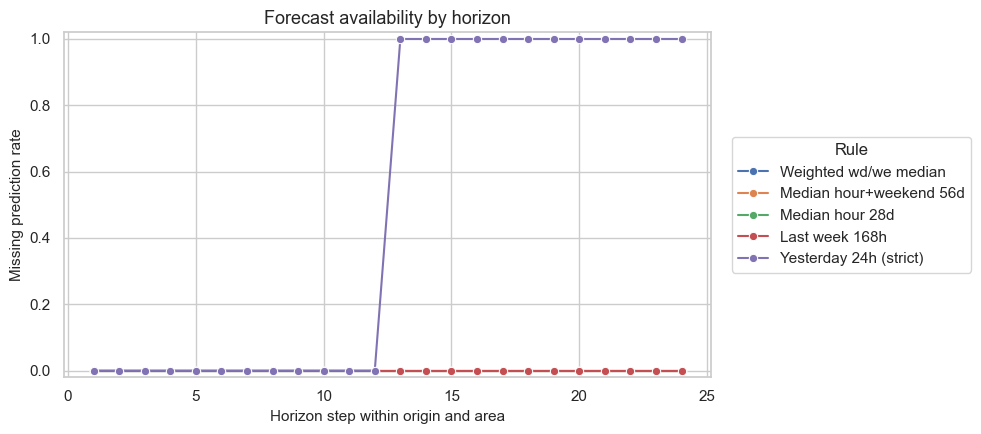

model,Last week 168h,Median hour 28d,Median hour+weekend 56d,Weighted wd/we median,Yesterday 24h (strict)
horizon,,,,,
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0


<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation.</strong> Availability is not bookkeeping noise. It is a forecast-origin fact, and it is why the strict 24-hour lag is a lesson rather than a production candidate.</div>

In [7]:
availability_by_horizon = (
    predictions.groupby(["model_label", "horizon"])["prediction_missing"]
    .mean()
    .reset_index()
)
availability_by_horizon = attach_model_display(availability_by_horizon)

fig, ax = plt.subplots(figsize=(10, 4.5))
if sns is not None:
    sns.lineplot(data=availability_by_horizon, x="horizon", y="prediction_missing", hue="model", marker="o", ax=ax)
else:
    for model, frame in availability_by_horizon.groupby("model"):
        ax.plot(frame["horizon"], frame["prediction_missing"], marker="o", label=model)
ax.legend(title="Rule", loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title("Forecast availability by horizon")
ax.set_xlabel("Horizon step within origin and area")
ax.set_ylabel("Missing prediction rate")
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

availability_table = availability_by_horizon.pivot(index="horizon", columns="model", values="prediction_missing")
display(availability_table.head(30))
interpretation("Availability is not bookkeeping noise. It is a forecast-origin fact, and it is why the strict 24-hour lag is a lesson rather than a production candidate.")


## 8. Overall Scores

Now compare point accuracy. The aggregate table is useful, but read it with missing-rate and tail-risk diagnostics; a low average can hide an unusable availability pattern or a very fragile error distribution.


,display_label,model_label,area,rows,evaluated_rows,mae,rmse,bias,missing_rate,p90_abs_error,p99_abs_error
4,Yesterday 24h (strict),same_hour_yesterday_strict,ALL,384,192,199.009879,284.543325,42.542612,0.5,581.436244,849.838477
0,Weighted wd/we median,median_weekday_exp_hl4_floor10_42d__median_wee...,ALL,384,384,247.258924,412.627319,-84.027010,0.0,558.283801,1884.390043
1,Median hour+weekend 56d,rolling_median_hour_weekend_56d,ALL,384,384,265.442420,439.439903,-148.056248,0.0,603.334244,1915.846056
3,Last week 168h,same_hour_last_week,ALL,384,384,270.348535,536.890547,58.016223,0.0,602.652122,2388.663328
2,Median hour 28d,rolling_median_local_hour_28d,ALL,384,384,297.826841,458.954363,-133.278193,0.0,577.576255,1886.139879
13,Yesterday 24h (strict),same_hour_yesterday_strict,DK1,192,96,180.517023,272.483545,46.486950,0.5,463.763736,865.132704
5,Weighted wd/we median,median_weekday_exp_hl4_floor10_42d__median_wee...,DK1,192,192,250.293113,431.419382,-82.560965,0.0,591.737474,1887.752154
7,Median hour+weekend 56d,rolling_median_hour_weekend_56d,DK1,192,192,268.565540,450.330343,-147.350889,0.0,623.125611,1887.004603
11,Last week 168h,same_hour_last_week,DK1,192,192,271.822588,551.697834,64.214390,0.0,606.647306,2314.562604
9,Median hour 28d,rolling_median_local_hour_28d,DK1,192,192,298.802309,465.213828,-128.265980,0.0,587.876657,1846.501588


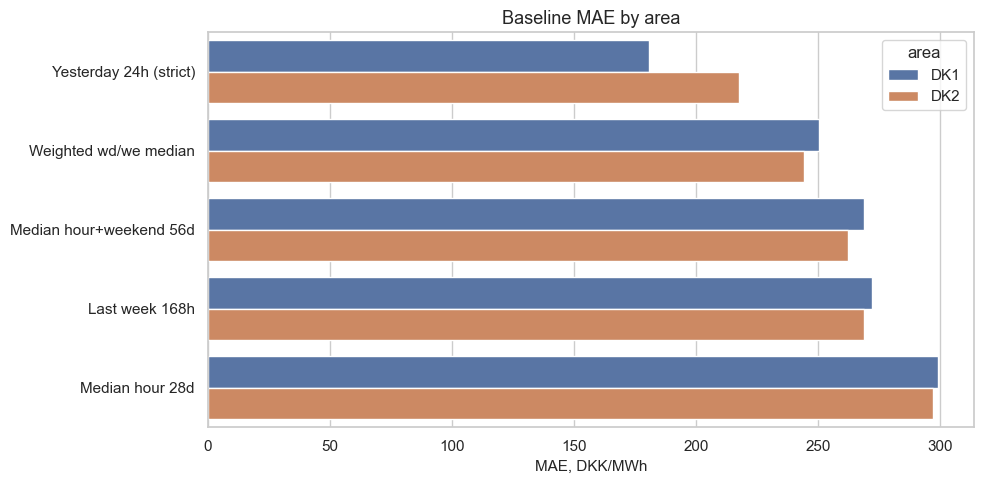

<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation.</strong> Best complete-coverage baseline on this slice: `Weighted wd/we median` with MAE 247.3. The robust median family is hard to beat because it uses the EDA structure while refusing to copy individual spikes too literally.</div>

In [8]:
def metric_rows(predictions: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (model_label, area), frame in predictions.groupby(["model_label", "area"]):
        rows.append(
            {
                "model_label": model_label,
                "area": area,
                "rows": len(frame),
                "evaluated_rows": int(frame["y_pred"].notna().sum()),
                "mae": mae(frame),
                "rmse": rmse(frame),
                "bias": bias(frame),
                "missing_rate": frame["y_pred"].isna().mean(),
                "p90_abs_error": frame["abs_error"].quantile(0.90),
                "p99_abs_error": frame["abs_error"].quantile(0.99),
            }
        )
    overall = []
    for model_label, frame in predictions.groupby("model_label"):
        overall.append(
            {
                "model_label": model_label,
                "area": "ALL",
                "rows": len(frame),
                "evaluated_rows": int(frame["y_pred"].notna().sum()),
                "mae": mae(frame),
                "rmse": rmse(frame),
                "bias": bias(frame),
                "missing_rate": frame["y_pred"].isna().mean(),
                "p90_abs_error": frame["abs_error"].quantile(0.90),
                "p99_abs_error": frame["abs_error"].quantile(0.99),
            }
        )
    return pd.concat([pd.DataFrame(overall), pd.DataFrame(rows)], ignore_index=True)


metrics = metric_rows(predictions).sort_values(["area", "mae", "model_label"])
display_metrics = attach_model_display(metrics, target="display_label")
display(display_metrics[["display_label", "model_label", "area", "rows", "evaluated_rows", "mae", "rmse", "bias", "missing_rate", "p90_abs_error", "p99_abs_error"]])

plot_metrics = attach_model_display(metrics.loc[metrics["area"].ne("ALL")])
fig, ax = plt.subplots(figsize=(10, 5))
if sns is not None:
    sns.barplot(data=plot_metrics, y="model", x="mae", hue="area", ax=ax)
else:
    plot_metrics.pivot(index="model", columns="area", values="mae").plot(kind="barh", ax=ax)
ax.set_title("Baseline MAE by area")
ax.set_xlabel("MAE, DKK/MWh")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

complete_overall = metrics.loc[(metrics["area"].eq("ALL")) & (metrics["missing_rate"].eq(0))].sort_values("mae")
if not complete_overall.empty:
    best_complete = complete_overall.iloc[0]
    interpretation(
        f"Best complete-coverage baseline on this slice: `{model_display_name(best_complete['model_label'])}` with MAE {best_complete['mae']:,.1f}. "
        "The robust median family is hard to beat because it uses the EDA structure while refusing to copy individual spikes too literally."
    )


## 9. Why Same-Hour-Last-Week Is High Variance

`same_hour_last_week` is often sensible, but it is a single historical observation. That makes it a high-variance estimator: excellent when last week was representative, poor when last week was a spike, a dip, or a different regime.


,display_label,model_label,mae,median_abs_error,p90_abs_error,p99_abs_error,error_std
0,Yesterday 24h (strict),same_hour_yesterday_strict,199.009879,128.976578,581.436244,849.838477,282.080581
1,Weighted wd/we median,median_weekday_exp_hl4_floor10_42d__median_wee...,247.258924,138.668786,558.283801,1884.390043,404.508192
2,Median hour+weekend 56d,rolling_median_hour_weekend_56d,265.442420,159.953276,603.334244,1915.846056,414.287025
3,Last week 168h,same_hour_last_week,270.348535,128.146352,602.652122,2388.663328,534.443078
4,Median hour 28d,rolling_median_local_hour_28d,297.826841,203.111060,577.576255,1886.139879,439.749501


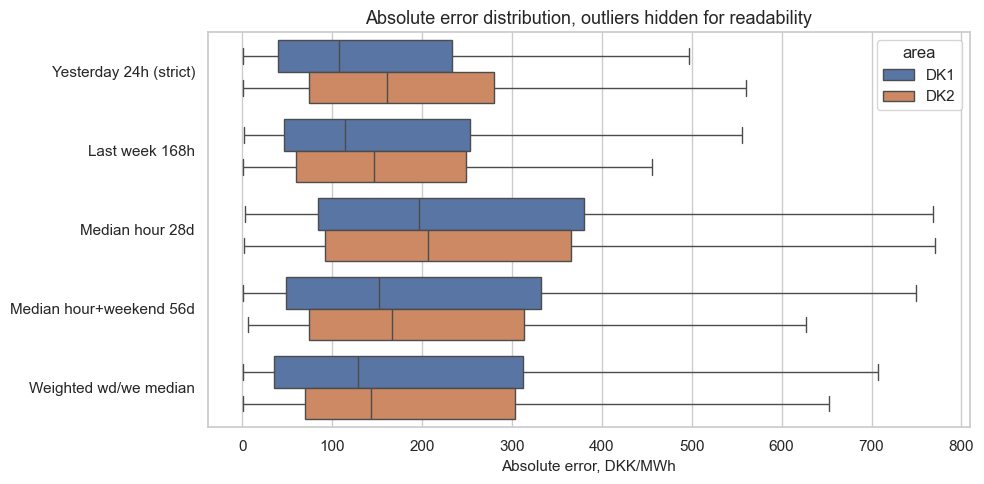

,area,forecast_origin_utc,ds_local,local_hour,y,y_pred,error,abs_error
692,DK1,2026-06-30 10:00:00+00:00,2026-07-01 20:00:00+02:00,20,1764.991072,5203.247084,3438.256012,3438.256012
716,DK2,2026-06-30 10:00:00+00:00,2026-07-01 20:00:00+02:00,20,1763.197153,5109.541549,3346.344396,3346.344396
693,DK1,2026-06-30 10:00:00+00:00,2026-07-01 21:00:00+02:00,21,1863.318112,5181.418523,3318.100411,3318.100411
717,DK2,2026-06-30 10:00:00+00:00,2026-07-01 21:00:00+02:00,21,1853.096730,5088.124316,3235.027586,3235.027586
691,DK1,2026-06-30 10:00:00+00:00,2026-07-01 19:00:00+02:00,19,1280.587380,3495.898993,2215.311612,2215.311612
715,DK2,2026-06-30 10:00:00+00:00,2026-07-01 19:00:00+02:00,19,1291.444114,3439.645758,2148.201644,2148.201644
694,DK1,2026-06-30 10:00:00+00:00,2026-07-01 22:00:00+02:00,22,1515.884679,3619.057732,2103.173052,2103.173052
718,DK2,2026-06-30 10:00:00+00:00,2026-07-01 22:00:00+02:00,22,1509.138915,3553.927483,2044.788568,2044.788568
405,DK1,2026-06-24 10:00:00+00:00,2026-06-25 21:00:00+02:00,21,1543.073151,3404.837965,1861.764814,1861.764814
740,DK1,2026-07-01 10:00:00+00:00,2026-07-02 20:00:00+02:00,20,348.489190,2199.689290,1851.200100,1851.200100


<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation.</strong> The last-week rule's p99 absolute error is 2,388.7, versus 1,915.8 for the equal rolling weekday/weekend median. This is the practical reason for robust pooling: medians give up some reactivity to reduce tail-copying.</div>

In [9]:
tail = (
    predictions.dropna(subset=["y_pred"])
    .groupby("model_label")
    .agg(
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        p90_abs_error=("abs_error", lambda values: values.quantile(0.90)),
        p99_abs_error=("abs_error", lambda values: values.quantile(0.99)),
        error_std=("error", "std"),
    )
    .sort_values("mae")
    .reset_index()
)
tail = attach_model_display(tail, target="display_label")
display(tail[["display_label", "model_label", "mae", "median_abs_error", "p90_abs_error", "p99_abs_error", "error_std"]])

fig, ax = plt.subplots(figsize=(10, 5))
plot_frame = attach_model_display(predictions.dropna(subset=["y_pred"]))
if sns is not None:
    sns.boxplot(data=plot_frame, y="model", x="abs_error", hue="area", showfliers=False, ax=ax)
else:
    plot_frame.boxplot(column="abs_error", by=["model", "area"], ax=ax, rot=30)
ax.set_title("Absolute error distribution, outliers hidden for readability")
ax.set_xlabel("Absolute error, DKK/MWh")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

lag_failures = (
    predictions.loc[predictions["model_label"].eq("same_hour_last_week")]
    .dropna(subset=["y_pred"])
    .nlargest(10, "abs_error")
    [["area", "forecast_origin_utc", "ds_local", "local_hour", "y", "y_pred", "error", "abs_error"]]
)
display(lag_failures)

lag_row = tail.loc[tail["model_label"].eq("same_hour_last_week")]
median_row = tail.loc[tail["model_label"].eq("rolling_median_hour_weekend_56d")]
if not lag_row.empty and not median_row.empty:
    lag_p99 = lag_row["p99_abs_error"].iloc[0]
    median_p99 = median_row["p99_abs_error"].iloc[0]
    interpretation(
        f"The last-week rule's p99 absolute error is {lag_p99:,.1f}, versus {median_p99:,.1f} for the equal rolling weekday/weekend median. "
        "This is the practical reason for robust pooling: medians give up some reactivity to reduce tail-copying."
    )


## 10. Robust Response: Rolling Medians

A rolling median pools historical rows with the same seasonal identity. The key design question is how much to condition:

- `local_hour` only gives more samples.
- `local_hour + is_weekend` gives fewer samples but a cleaner calendar bucket.

This is a tiny didactic sweep. The plot is deliberately shown as grouped bars, not a smooth curve: with only two lookbacks, the point is to compare robustness choices, not infer a continuous optimum.

,display_label,model_label,mae,p90_abs_error,p99_abs_error,missing_rate
2,"hour + weekend, 28d",median_hour_weekend_28d,255.942264,573.989994,1788.092795,0.0
3,"hour + weekend, 56d",median_hour_weekend_56d,265.442420,603.334244,1915.846056,0.0
0,"hour only, 28d",median_hour_28d,297.826841,577.576255,1886.139879,0.0
1,"hour only, 56d",median_hour_56d,305.912689,623.577101,1969.486873,0.0


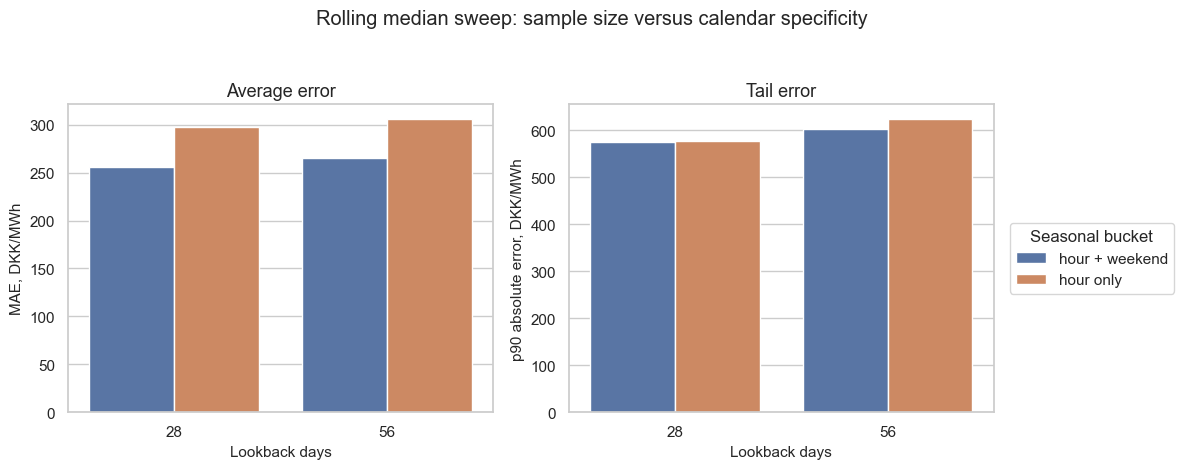

<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation.</strong> The best rolling-median sweep candidate here is `hour + weekend, 28d`. Read the grouped bars as a robustness check: adding weekend conditioning can reduce calendar bias, while longer lookbacks can reduce variance by giving each bucket more historical rows.</div>

In [10]:
sweep_origins = origins.tail(min(ROLLING_SWEEP_MAX_ORIGINS, len(origins))).reset_index(drop=True)
sweep_specs = {}
for lookback_days in [28, 56]:
    sweep_specs[f"median_hour_{lookback_days}d"] = lambda lookback_days=lookback_days: SeasonalRollingMedian(
        lookback_days=lookback_days,
        seasonal_keys=("local_hour",),
        min_periods=7,
    )
    sweep_specs[f"median_hour_weekend_{lookback_days}d"] = lambda lookback_days=lookback_days: SeasonalRollingMedian(
        lookback_days=lookback_days,
        seasonal_keys=("local_hour", "is_weekend"),
        min_periods=4,
    )

sweep_frames = []
for model_label, factory in sweep_specs.items():
    preds = rolling_origin_backtest(
        model_factory=factory,
        panel=panel,
        origins=sweep_origins,
        horizon_builder=delivery_day_horizon_builder,
        min_train_rows=24 * 21 * panel["area"].nunique(),
    )
    preds["model_label"] = model_label
    sweep_frames.append(preds)

sweep_predictions = pd.concat(sweep_frames, ignore_index=True)
sweep_predictions["error"] = sweep_predictions["y_pred"] - sweep_predictions["y"]
sweep_predictions["abs_error"] = sweep_predictions["error"].abs()
sweep_predictions["prediction_missing"] = sweep_predictions["y_pred"].isna()
sweep_metrics = metric_rows(sweep_predictions)
sweep_overall = sweep_metrics.loc[sweep_metrics["area"].eq("ALL")].sort_values("mae")

plot_sweep = sweep_overall.copy()
plot_sweep["seasonal_bucket"] = np.where(plot_sweep["model_label"].str.contains("weekend"), "hour + weekend", "hour only")
plot_sweep["lookback_days"] = plot_sweep["model_label"].str.extract(r"_(\d+)d").astype(int)
plot_sweep["display_label"] = plot_sweep["seasonal_bucket"] + ", " + plot_sweep["lookback_days"].astype(str) + "d"
display(plot_sweep[["display_label", "model_label", "mae", "p90_abs_error", "p99_abs_error", "missing_rate"]].sort_values("mae"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
if sns is not None:
    sns.barplot(data=plot_sweep, x="lookback_days", y="mae", hue="seasonal_bucket", ax=axes[0])
    sns.barplot(data=plot_sweep, x="lookback_days", y="p90_abs_error", hue="seasonal_bucket", ax=axes[1])
else:
    plot_sweep.pivot(index="lookback_days", columns="seasonal_bucket", values="mae").plot(kind="bar", ax=axes[0])
    plot_sweep.pivot(index="lookback_days", columns="seasonal_bucket", values="p90_abs_error").plot(kind="bar", ax=axes[1])
axes[0].set_title("Average error")
axes[0].set_xlabel("Lookback days")
axes[0].set_ylabel("MAE, DKK/MWh")
axes[1].set_title("Tail error")
axes[1].set_xlabel("Lookback days")
axes[1].set_ylabel("p90 absolute error, DKK/MWh")
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
axes[1].legend(handles, labels, title="Seasonal bucket", loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.suptitle("Rolling median sweep: sample size versus calendar specificity", y=1.04)
plt.tight_layout()
plt.show()

best_sweep = sweep_overall.iloc[0]
interpretation(
    f"The best rolling-median sweep candidate here is `{plot_sweep.loc[plot_sweep['model_label'].eq(best_sweep['model_label']), 'display_label'].iloc[0]}`. "
    "Read the grouped bars as a robustness check: adding weekend conditioning can reduce calendar bias, while longer lookbacks can reduce variance by giving each bucket more historical rows."
)


## 11. Recency Versus Sample Size: Weighted Medians

Equal medians treat all rows in the lookback window as exchangeable. That is not quite right under drift: yesterday is usually more relevant than six weeks ago. But if we discount too aggressively, the median stops being robust because only a few recent rows matter.

The weighted median keeps the same transparent seasonal bucket, then adds three knobs:

- `lookback_days`: how much history is eligible.
- `half_life_days`: how quickly old rows lose influence.
- `floor`: how much old history is protected from being discounted to near-zero.

The notebook-scale plot below is a sensitivity surface: each line is a weighting rule and the x-axis is the lookback. It is easier to read than a leaderboard of long candidate names, and it better matches the conceptual question: does recency help enough to pay for the loss of effective sample size?

,day_type,display_label,model_label,mae,rmse,bias,evaluated_rows
6,weekday,"exp hl4, 42d",median_exp_hl4_42d,276.267699,464.736686,-14.313385,288
7,weekday,"exp hl4, 56d",median_exp_hl4_56d,276.267699,464.736686,-14.313385,288
8,weekday,"exp hl4 floor10, 42d",median_exp_hl4_floor10_42d,288.559952,464.924036,-88.095534,288
9,weekday,"exp hl4 floor10, 56d",median_exp_hl4_floor10_56d,299.931117,482.646585,-115.202112,288
2,weekday,"exp hl28, 42d",median_exp_hl28_42d,303.645827,482.699765,-161.798484,288
4,weekday,"exp hl28 floor10, 42d",median_exp_hl28_floor10_42d,303.675457,481.934862,-164.965571,288
0,weekday,"equal, 42d",median_equal_42d,308.934586,489.375465,-177.865678,288
3,weekday,"exp hl28, 56d",median_exp_hl28_56d,308.997042,489.999663,-162.909342,288
19,weekend,"exp hl4 floor10, 56d",median_exp_hl4_floor10_56d,120.604809,176.449759,-65.779180,96
11,weekend,"equal, 56d",median_equal_56d,124.124982,182.522393,-71.247677,96


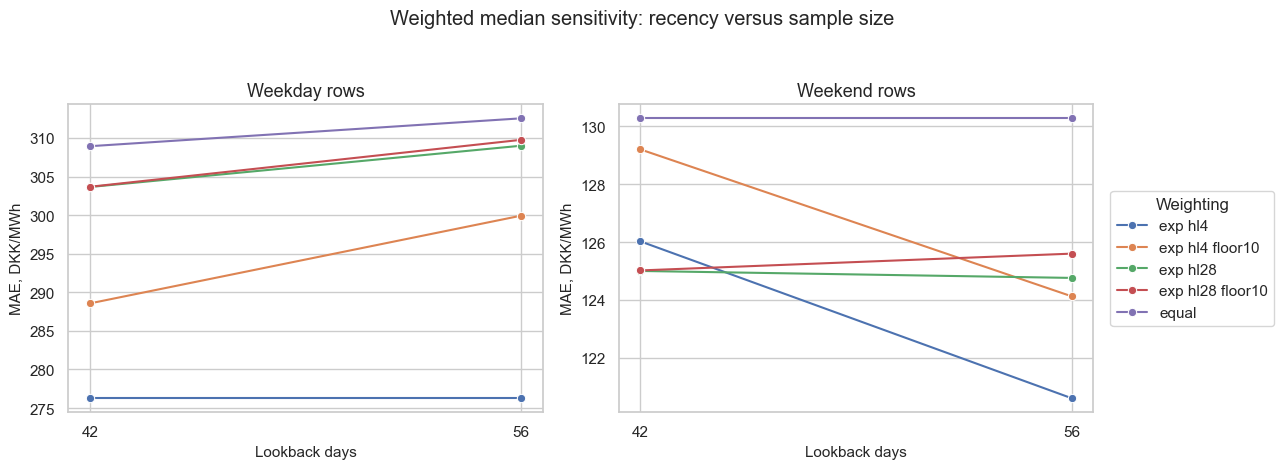

,day_type,display_label,model_label,mae,rmse,bias,evaluated_rows
6,weekday,"exp hl4, 42d",median_exp_hl4_42d,276.267699,464.736686,-14.313385,288
19,weekend,"exp hl4 floor10, 56d",median_exp_hl4_floor10_56d,120.604809,176.449759,-65.779180,96


<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation.</strong> Notebook-scale marginal selection picks `exp hl4, 42d` for weekdays and `exp hl4 floor10, 56d` for weekends. Treat this as a diagnostic surface, not the final word: the heavier artifact path uses Elspot for selection and DayAhead as a holdout to reduce selection-on-the-test-set temptation.</div>

In [11]:
def weighted_candidate_specs() -> dict[str, dict]:
    candidates: dict[str, dict] = {}
    for lookback_days in [42, 56]:
        candidates[f"median_equal_{lookback_days}d"] = {
            "lookback_days": lookback_days,
            "weight_family": "equal",
            "half_life_days": None,
            "floor": None,
        }
        for half_life_days in [4.0, 28.0]:
            for floor in [None, 0.10]:
                floor_label = "" if floor is None else f"_floor{int(floor * 100):02d}"
                label = f"median_exp_hl{int(half_life_days)}{floor_label}_{lookback_days}d"
                candidates[label] = {
                    "lookback_days": lookback_days,
                    "weight_family": "exponential",
                    "half_life_days": half_life_days,
                    "floor": floor,
                }
    return candidates


def weighted_factory(spec: dict) -> WeightedSeasonalMedian:
    return WeightedSeasonalMedian(
        lookback_days=spec["lookback_days"],
        seasonal_keys=("local_hour", "is_weekend"),
        min_periods=4,
        weight_family=spec["weight_family"],
        half_life_days=spec["half_life_days"],
        floor=spec["floor"],
    )


def weight_display_label(row: pd.Series) -> str:
    if row["weight_family"] == "equal" or pd.isna(row["half_life"]):
        return "equal"
    label = f"exp hl{int(row['half_life'])}"
    if not pd.isna(row["floor"]):
        label += f" floor{int(row['floor'] * 100)}"
    return label


weighted_grid_origins = origins.tail(min(WEIGHTED_NOTEBOOK_MAX_ORIGINS, len(origins))).reset_index(drop=True)
weighted_frames = []
for model_label, spec in weighted_candidate_specs().items():
    preds = rolling_origin_backtest(
        model_factory=lambda spec=spec: weighted_factory(spec),
        panel=panel,
        origins=weighted_grid_origins,
        horizon_builder=delivery_day_horizon_builder,
        min_train_rows=24 * 21 * panel["area"].nunique(),
    )
    preds["model_label"] = model_label
    preds["lookback_days"] = spec["lookback_days"]
    preds["weight_family"] = spec["weight_family"]
    preds["half_life"] = spec["half_life_days"]
    preds["floor"] = spec["floor"]
    weighted_frames.append(preds)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="The behavior of DataFrame concatenation", category=FutureWarning)
    weighted_predictions = pd.concat(weighted_frames, ignore_index=True)
weighted_predictions["error"] = weighted_predictions["y_pred"] - weighted_predictions["y"]
weighted_predictions["abs_error"] = weighted_predictions["error"].abs()
weighted_predictions["day_type"] = np.where(weighted_predictions["is_weekend"].astype(bool), "weekend", "weekday")

weighted_scores = (
    weighted_predictions.dropna(subset=["y_pred"])
    .groupby(["day_type", "model_label", "lookback_days", "weight_family", "half_life", "floor"], dropna=False)
    .agg(
        evaluated_rows=("y_pred", "size"),
        mae=("abs_error", "mean"),
        rmse=("error", lambda values: float(np.sqrt(np.mean(np.square(values))))),
        bias=("error", "mean"),
    )
    .reset_index()
    .sort_values(["day_type", "mae", "rmse", "model_label"])
)
weighted_scores["weight_label"] = weighted_scores.apply(weight_display_label, axis=1)
weighted_scores["display_label"] = weighted_scores["weight_label"] + ", " + weighted_scores["lookback_days"].astype(str) + "d"

best_marginal = weighted_scores.groupby("day_type", as_index=False).head(8)
display(best_marginal[["day_type", "display_label", "model_label", "mae", "rmse", "bias", "evaluated_rows"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
legend_handles, legend_labels = None, None
for ax, day_type in zip(axes, ["weekday", "weekend"]):
    frame = weighted_scores[weighted_scores["day_type"].eq(day_type)].copy()
    if frame.empty:
        ax.text(0.5, 0.5, f"No {day_type} rows in this compact slice", ha="center", va="center")
        ax.set_axis_off()
        continue
    if sns is not None:
        sns.lineplot(data=frame, x="lookback_days", y="mae", hue="weight_label", marker="o", ax=ax)
    else:
        for label, label_frame in frame.groupby("weight_label"):
            ax.plot(label_frame["lookback_days"], label_frame["mae"], marker="o", label=label)
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    ax.set_title(f"{day_type.title()} rows")
    ax.set_xlabel("Lookback days")
    ax.set_ylabel("MAE, DKK/MWh")
    ax.set_xticks(sorted(frame["lookback_days"].unique()))
if legend_handles is not None:
    axes[-1].legend(legend_handles, legend_labels, title="Weighting", loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.suptitle("Weighted median sensitivity: recency versus sample size", y=1.04)
plt.tight_layout()
plt.show()

selected = weighted_scores.groupby("day_type", as_index=False).head(1)
display(selected[["day_type", "display_label", "model_label", "mae", "rmse", "bias", "evaluated_rows"]])
selected_labels = dict(zip(selected["day_type"], selected["display_label"])) if not selected.empty else {}
if {"weekday", "weekend"}.issubset(selected_labels):
    interpretation(
        f"Notebook-scale marginal selection picks `{selected_labels['weekday']}` for weekdays and `{selected_labels['weekend']}` for weekends. "
        "Treat this as a diagnostic surface, not the final word: the heavier artifact path uses Elspot for selection and DayAhead as a holdout to reduce selection-on-the-test-set temptation."
    )
elif selected_labels:
    present = ", ".join(sorted(selected_labels))
    interpretation(
        f"This compact notebook slice only produced scored rows for: {present}. "
        "Increase `WEIGHTED_NOTEBOOK_MAX_ORIGINS` if you want both weekday and weekend marginal reads inside the notebook."
    )
else:
    interpretation(
        "The compact weighted-median diagnostic produced no scored rows. Increase the notebook origin count or run the full artifact path for selection evidence."
    )


In [12]:
weighted_required_files = {
    "manifest": WEIGHTED_RESULT_DIR / "run_manifest.json",
    "elspot_scores": WEIGHTED_RESULT_DIR / "elspot_marginal_scores.parquet",
    "dayahead_scores": WEIGHTED_RESULT_DIR / "dayahead_marginal_scores.parquet",
    "selection": WEIGHTED_RESULT_DIR / "marginal_model_selection.parquet",
    "composite_scores": WEIGHTED_RESULT_DIR / "selected_composite_dayahead_scores.parquet",
}
missing_weighted = [path.relative_to(PROJECT_ROOT) for path in weighted_required_files.values() if not path.exists()]

if missing_weighted:
    display(Markdown(
        "Full weighted-median artifacts are not present. To produce the Elspot-selection / DayAhead-holdout tables, run:\n\n"
        "```bash\n"
        "python scripts/run_baseline_backtest.py --weighted-median-grid weekday-weekend\n"
        "```\n\n"
        f"Missing files: `{', '.join(str(path) for path in missing_weighted)}`"
    ))
else:
    weighted_manifest = json.loads(weighted_required_files["manifest"].read_text(encoding="utf-8"))
    weighted_selection = pd.read_parquet(weighted_required_files["selection"])
    weighted_composite_scores = pd.read_parquet(weighted_required_files["composite_scores"])
    weighted_elspot_scores = pd.read_parquet(weighted_required_files["elspot_scores"])
    weighted_dayahead_scores = pd.read_parquet(weighted_required_files["dayahead_scores"])

    display(Markdown(
        f"Loaded **{weighted_manifest['candidate_count']}** full weighted-median candidates. "
        f"Elspot origins: **{weighted_manifest['elspot_origin_count']}**; "
        f"DayAhead origins: **{weighted_manifest['dayahead_origin_count']}**."
    ))
    display(weighted_selection)
    display(weighted_composite_scores.sort_values("area"))

    for source_name, scores in [("Elspot tuning", weighted_elspot_scores), ("DayAhead holdout", weighted_dayahead_scores)]:
        display(Markdown(f"### {source_name} top marginal rules"))
        top = (
            scores.loc[scores["area"].eq("ALL")]
            .sort_values(["day_type", "mae", "rmse", "model_label"])
            .groupby("day_type", as_index=False)
            .head(8)
        )
        display(top[["day_type", "model_label", "mae", "lookback_days", "half_life", "floor", "missing_rate"]])

    production_labels = {
        "weekday": "median_weekday_exp_hl4_floor10_42d",
        "weekend": "median_weekend_exp_hl28_floor20_56d",
    }
    production_rows = []
    for day_type, label in production_labels.items():
        row = weighted_dayahead_scores.loc[
            weighted_dayahead_scores["area"].eq("ALL")
            & weighted_dayahead_scores["day_type"].eq(day_type)
            & weighted_dayahead_scores["model_label"].eq(label)
        ]
        if not row.empty:
            production_rows.append(row.iloc[0])
    production_combo_mae = np.nan
    if len(production_rows) == 2:
        production_frame = pd.DataFrame(production_rows)
        production_combo_mae = float(
            production_frame["mae"].mul(production_frame["evaluated_rows"]).sum()
            / production_frame["evaluated_rows"].sum()
        )
        display(Markdown("### Current promoted weighted-median combo on DayAhead"))
        display(production_frame[["day_type", "model_label", "mae", "lookback_days", "half_life", "floor", "evaluated_rows"]])

    selected_all_mae = float(weighted_composite_scores.loc[weighted_composite_scores["area"].eq("ALL"), "mae"].iloc[0])
    comparison_rows = [{"selection_protocol": "Elspot-selected marginal composite", "dayahead_mae": selected_all_mae}]
    if np.isfinite(production_combo_mae):
        comparison_rows.append({"selection_protocol": "Current promoted DayAhead-marginal combo", "dayahead_mae": production_combo_mae})
    comparison = pd.DataFrame(comparison_rows).sort_values("dayahead_mae")
    display(comparison)

    if np.isfinite(production_combo_mae):
        interpretation(
            f"The full Elspot-selected weekday/weekend composite transfers to DayAhead at MAE {selected_all_mae:,.2f}. "
            f"The current promoted combo scores {production_combo_mae:,.2f} on the same DayAhead marginal diagnostic. "
            "This is the distribution-shift lesson in miniature: old Elspot history picks a slightly different weekend/weekday rule than the DayAhead period. "
            "Do not blindly retune production to either side from one table; use this as evidence for a conservative promotion policy."
        )
    else:
        interpretation(
            f"The full selected weekday/weekend composite lands at DayAhead MAE {selected_all_mae:,.2f}. "
            "Because selection happens on Elspot and reporting happens on DayAhead, this is a transfer check rather than another tuning score."
        )


Loaded **133** full weighted-median candidates. Elspot origins: **5391**; DayAhead origins: **276**.

,day_type,model_label,lookback_days,weight_family,half_life,floor,elspot_mae,elspot_rmse,elspot_bias,elspot_missing_rate,dayahead_mae,dayahead_rmse,dayahead_bias,dayahead_missing_rate
0,weekday,median_weekday_exp_hl4_floor05_42d,42,exponential,4.0,0.05,131.331469,286.494582,3.599572,0.0,226.626313,342.328323,-8.265036,0.0
1,weekend,median_weekend_exp_hl10_84d,84,exponential,10.0,NaN,126.490229,265.166921,10.791275,0.0,198.626054,273.031950,26.591965,0.0


,model_label,area,rows,evaluated_rows,mae,rmse,bias,coverage,interval_width,missing_rate
0,weekday_weekend_weighted_median_composite,ALL,13248,13248,218.713197,324.249309,1.585856,NaN,NaN,0.0
1,weekday_weekend_weighted_median_composite,DK1,6624,6624,210.062915,311.641354,-1.657991,NaN,NaN,0.0
2,weekday_weekend_weighted_median_composite,DK2,6624,6624,227.363479,336.385041,4.829702,NaN,NaN,0.0


### Elspot tuning top marginal rules

,day_type,model_label,mae,lookback_days,half_life,floor,missing_rate
0,weekday,median_weekday_exp_hl4_floor05_42d,131.331469,42,4.0,0.05,0.0
1,weekday,median_weekday_exp_hl4_56d,131.485608,56,4.0,NaN,0.0
2,weekday,median_weekday_exp_hl4_42d,131.491342,42,4.0,NaN,0.0
3,weekday,median_weekday_exp_hl4_floor05_56d,131.541581,56,4.0,0.05,0.0
4,weekday,median_weekday_exp_hl4_28d,131.557598,28,4.0,NaN,0.0
5,weekday,median_weekday_exp_hl4_floor05_28d,131.649160,28,4.0,0.05,0.0
6,weekday,median_weekday_exp_hl5_56d,132.024534,56,5.0,NaN,0.0
7,weekday,median_weekday_exp_hl5_42d,132.041665,42,5.0,NaN,0.0
171,weekend,median_weekend_exp_hl10_84d,126.490229,84,10.0,NaN,0.0
172,weekend,median_weekend_exp_hl10_floor10_35d,126.625548,35,10.0,0.10,0.0


...

,day_type,model_label,mae,lookback_days,half_life,floor,missing_rate
0,weekday,median_weekday_exp_hl4_floor10_42d,224.256398,42,4.0,0.10,0.0
1,weekday,median_weekday_exp_hl5_floor10_42d,224.772186,42,5.0,0.10,0.0
2,weekday,median_weekday_exp_hl4_floor10_56d,224.969245,56,4.0,0.10,0.0
3,weekday,median_weekday_exp_hl5_floor10_56d,225.466683,56,5.0,0.10,0.0
4,weekday,median_weekday_exp_hl6_floor10_42d,225.679883,42,6.0,0.10,0.0
5,weekday,median_weekday_exp_hl4_floor05_56d,225.747296,56,4.0,0.05,0.0
6,weekday,median_weekday_exp_hl6_floor10_56d,225.800882,56,6.0,0.10,0.0
7,weekday,median_weekday_exp_hl6_floor05_56d,225.812778,56,6.0,0.05,0.0
171,weekend,median_weekend_exp_hl28_floor20_56d,196.157393,56,28.0,0.20,0.0
172,weekend,median_weekend_exp_hl28_floor10_56d,196.270571,56,28.0,0.10,0.0


### Current promoted weighted-median combo on DayAhead

,day_type,model_label,mae,lookback_days,half_life,floor,evaluated_rows
0,weekday,median_weekday_exp_hl4_floor10_42d,224.256398,42,4.0,0.1,9504
171,weekend,median_weekend_exp_hl28_floor20_56d,196.157393,56,28.0,0.2,3744


,selection_protocol,dayahead_mae
1,Current promoted DayAhead-marginal combo,216.315375
0,Elspot-selected marginal composite,218.713197


<div style="color:#b42318; border-left:4px solid #b42318; padding:0.35rem 0 0.35rem 0.8rem; margin:0.75rem 0;"><strong>Interpretation.</strong> The full Elspot-selected weekday/weekend composite transfers to DayAhead at MAE 218.71. The current promoted combo scores 216.32 on the same DayAhead marginal diagnostic. This is the distribution-shift lesson in miniature: old Elspot history picks a slightly different weekend/weekday rule than the DayAhead period. Do not blindly retune production to either side from one table; use this as evidence for a conservative promotion policy.</div>

## 12. One Delivery Day Under The Microscope

A single delivery day cannot select a model, but it often explains a score. Here we look at the promoted baselines on one origin.


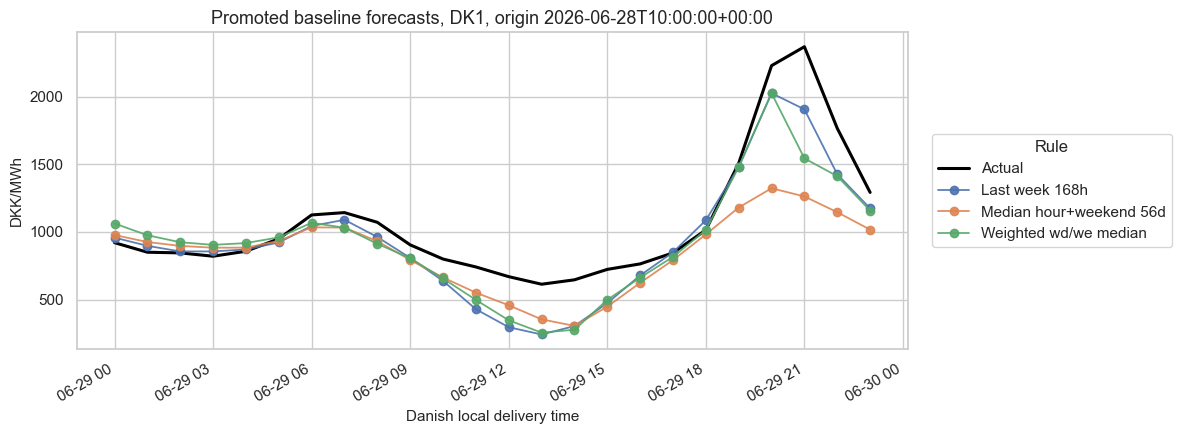

,model,model_label,ds_local,y,y_pred,error
1728,Weighted wd/we median,median_weekday_exp_hl4_floor10_42d__median_wee...,2026-06-29 00:00:00+02:00,920.241756,1061.793803,141.552047
1344,Median hour+weekend 56d,rolling_median_hour_weekend_56d,2026-06-29 00:00:00+02:00,920.241756,976.807895,56.566139
576,Last week 168h,same_hour_last_week,2026-06-29 00:00:00+02:00,920.241756,957.415618,37.173862
1729,Weighted wd/we median,median_weekday_exp_hl4_floor10_42d__median_wee...,2026-06-29 01:00:00+02:00,849.589035,975.229761,125.640727
1345,Median hour+weekend 56d,rolling_median_hour_weekend_56d,2026-06-29 01:00:00+02:00,849.589035,925.171572,75.582537
577,Last week 168h,same_hour_last_week,2026-06-29 01:00:00+02:00,849.589035,897.001366,47.412331
1730,Weighted wd/we median,median_weekday_exp_hl4_floor10_42d__median_wee...,2026-06-29 02:00:00+02:00,844.730612,923.463621,78.733009
1346,Median hour+weekend 56d,rolling_median_hour_weekend_56d,2026-06-29 02:00:00+02:00,844.730612,896.267658,51.537046
578,Last week 168h,same_hour_last_week,2026-06-29 02:00:00+02:00,844.730612,855.460730,10.730119
1731,Weighted wd/we median,median_weekday_exp_hl4_floor10_42d__median_wee...,2026-06-29 03:00:00+02:00,820.064769,904.052874,83.988104


In [13]:
promoted_labels = [
    "same_hour_last_week",
    "rolling_median_hour_weekend_56d",
    "median_weekday_exp_hl4_floor10_42d__median_weekend_exp_hl28_floor20_56d",
]
example_origin = predictions["forecast_origin_utc"].drop_duplicates().sort_values().iloc[len(origins) // 2]
example_area = "DK1" if "DK1" in predictions["area"].unique() else predictions["area"].iloc[0]
example = predictions.loc[
    predictions["forecast_origin_utc"].eq(example_origin)
    & predictions["area"].eq(example_area)
    & predictions["model_label"].isin(promoted_labels)
].copy()
example = attach_model_display(example)

fig, ax = plt.subplots(figsize=(12, 4.5))
actual = example.drop_duplicates("ds_utc").sort_values("ds_utc")
ax.plot(actual["ds_local"], actual["y"], color="black", linewidth=2.2, label="Actual")
for model, frame in example.groupby("model"):
    frame = frame.sort_values("ds_utc")
    ax.plot(frame["ds_local"], frame["y_pred"], marker="o", linewidth=1.3, alpha=0.9, label=model)
ax.set_title(f"Promoted baseline forecasts, {example_area}, origin {example_origin.isoformat()}")
ax.set_xlabel("Danish local delivery time")
ax.set_ylabel("DKK/MWh")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Rule")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

display(example[["model", "model_label", "ds_local", "y", "y_pred", "error"]].sort_values(["ds_local", "model_label"]).head(18))


## 13. Handoff To CatBoost

The baseline lesson is now precise enough to hand to tabular ML:

- Weekly/daily autocorrelation justifies lag features.
- Point lags are useful but high variance.
- Rolling medians are robust seasonal estimators.
- The weekday/weekend weighted median is not just a competitor; it is a strong prior about the price level.

That last point is what motivates the next notebook. CatBoost should not have to rediscover the entire seasonal level from scratch. It can consume robust baseline predictions, raw lags, rolling summaries, calendar fields, and area-spread features. If the robust baseline dominates feature importance, the natural next step is residual modeling: predict the deviation from the baseline rather than the level itself.
